In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# 1. Load data
df = pd.read_csv("/content/drive/MyDrive/file/shopify_stock.csv")
df

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800000,2.874000,2.411000,2.568000,2.568000,123039000
1,2015-05-22 00:00:00-04:00,2.607000,3.110000,2.600000,2.831000,2.831000,28412000
2,2015-05-26 00:00:00-04:00,2.980000,3.034000,2.908000,2.965000,2.965000,8202000
3,2015-05-27 00:00:00-04:00,3.067000,3.081000,2.700000,2.750000,2.750000,7976000
4,2015-05-28 00:00:00-04:00,2.755000,2.774000,2.648000,2.745000,2.745000,4000000
...,...,...,...,...,...,...,...
2464,2025-03-10 00:00:00-04:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300
2465,2025-03-11 00:00:00-04:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100
2466,2025-03-12 00:00:00-04:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900
2467,2025-03-13 00:00:00-04:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400


In [6]:
# 1 (2). Understand data
print(df.head())

                        date   open   high    low  close  adj_close     volume
0  2015-05-21 00:00:00-04:00  2.800  2.874  2.411  2.568      2.568  123039000
1  2015-05-22 00:00:00-04:00  2.607  3.110  2.600  2.831      2.831   28412000
2  2015-05-26 00:00:00-04:00  2.980  3.034  2.908  2.965      2.965    8202000
3  2015-05-27 00:00:00-04:00  3.067  3.081  2.700  2.750      2.750    7976000
4  2015-05-28 00:00:00-04:00  2.755  2.774  2.648  2.745      2.745    4000000


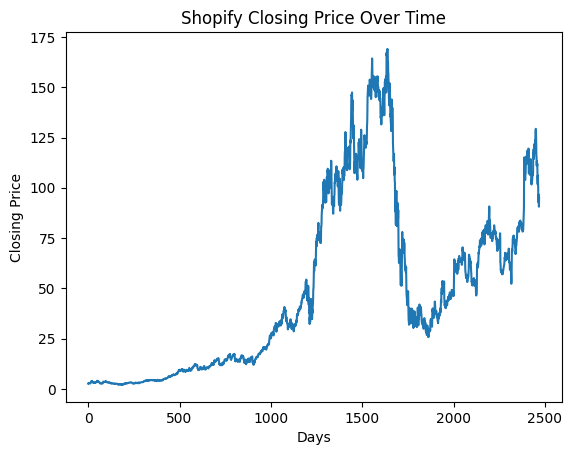

In [11]:
# 2. Data Visualization: Shopify Closing Price Over Time

plt.plot(df['close'])
plt.title('Shopify Closing Price Over Time')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.show()

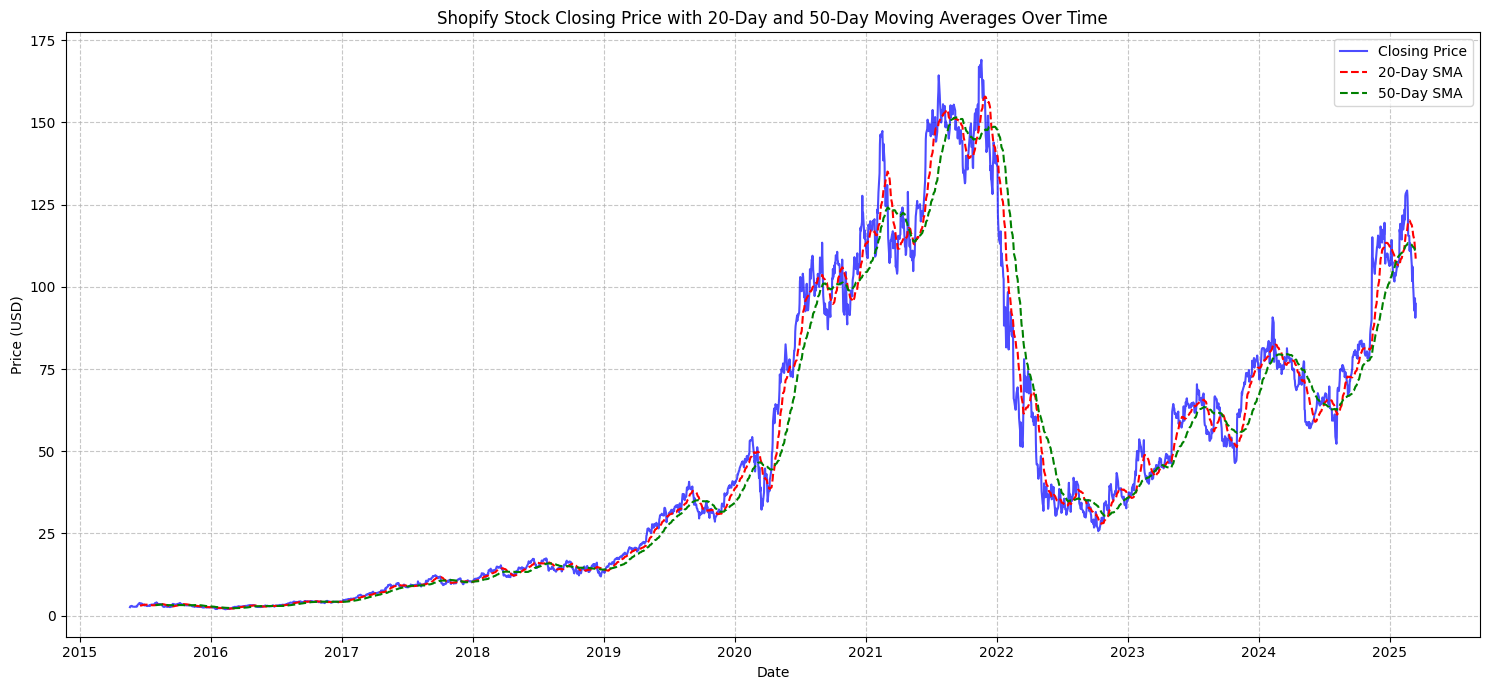

In [10]:
# 3. Calculate and Plot Moving Averages

# Calculate the 20-day Simple Moving Average (SMA)
df['SMA_20'] = df['close'].rolling(window=20).mean()

# Calculate the 50-day Simple Moving Average (SMA)
df['SMA_50'] = df['close'].rolling(window=50).mean()

# Plot the closing price and moving averages
plt.figure(figsize=(15, 7))
plt.plot(df['date'], df['close'], label='Closing Price', color='blue', alpha=0.7)
plt.plot(df['date'], df['SMA_20'], label='20-Day SMA', color='red', linestyle='--')
plt.plot(df['date'], df['SMA_50'], label='50-Day SMA', color='green', linestyle='--')

plt.title('Shopify Stock Closing Price with 20-Day and 50-Day Moving Averages Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

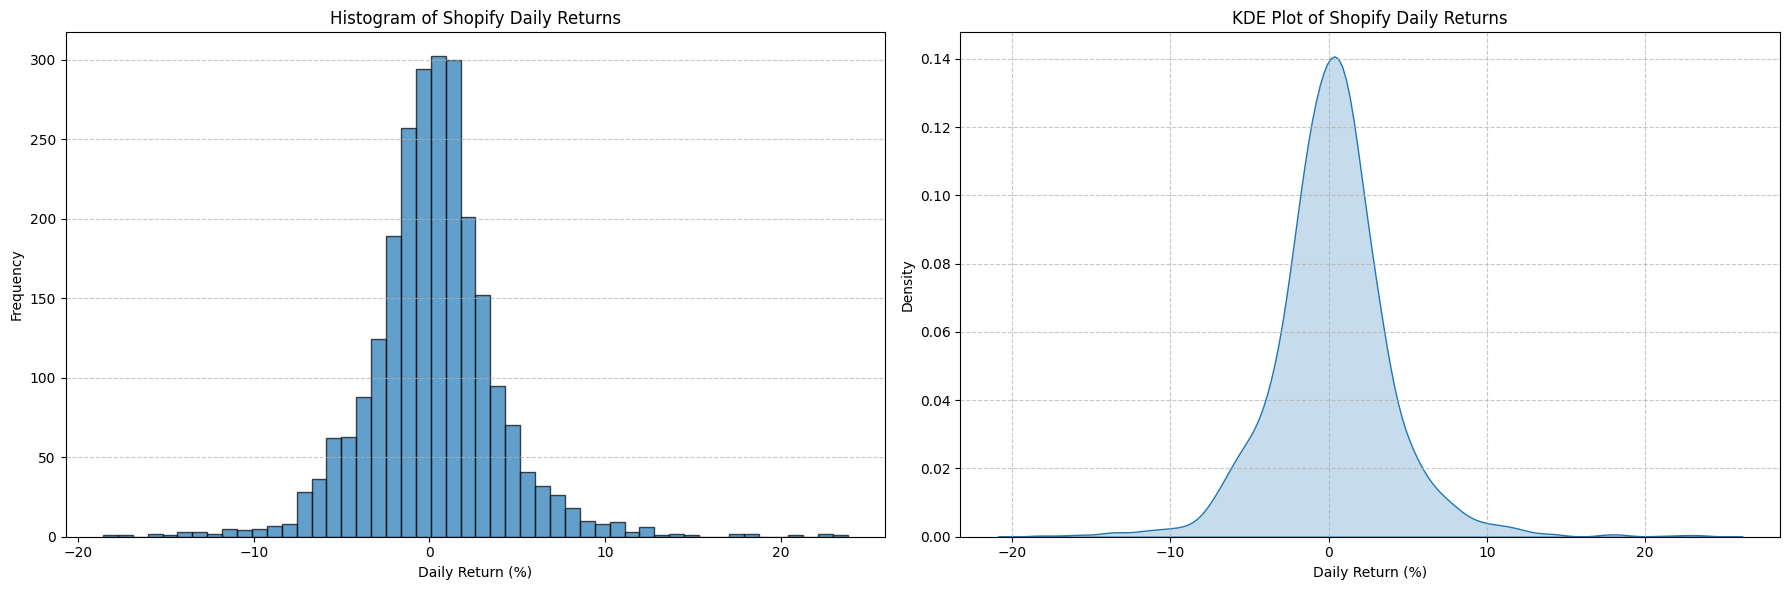

In [13]:
# 4. Calculate and Plot Daily Returns

# Calculate daily returns
df['Daily_Return'] = df['close'].pct_change() * 100 # Express as percentage

# Drop the first NaN value resulting from pct_change()
daily_returns = df['Daily_Return'].dropna()

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Plot 1: Histogram of Daily Returns
axes[0].hist(daily_returns, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Histogram of Shopify Daily Returns')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: KDE Plot of Daily Returns
import seaborn as sns # Ensure seaborn is imported
sns.kdeplot(daily_returns, fill=True, ax=axes[1])
axes[1].set_title('KDE Plot of Shopify Daily Returns')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Density')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()